# Visualisasi Hasil Evaluasi @40

Fokus visualisasi:
- perbandingan BM25 vs Hybrid_Final
- selisih metrik Hybrid terhadap BM25
- fairness vs exposure disparity
- metrik per query

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.35

EVAL_FILE = 'evaluation_results@40.csv'
df_eval = pd.read_csv(EVAL_FILE)

df_eval.head()

,Precision@40,Recall@40,NDCG@40,Fairness@40,ExposureDisparity@40,query,method
0,1.0,0.025707,1.000000,0.475,0.094343,tas wanita kulit,BM25
1,1.0,0.025707,0.983468,1.000,0.277276,tas wanita kulit,Hybrid_Final


In [4]:
# Ringkasan rata-rata otomatis dari evaluation_results@40.csv
metric_cols = [c for c in df_eval.columns if '@' in c and c not in ['query']]

df_summary = (
    df_eval.groupby('method')[metric_cols]
    .mean()
    .reset_index()
)

df_summary

,method,Precision@40,Recall@40,NDCG@40,Fairness@40,ExposureDisparity@40
0,BM25,1.0,0.025707,1.000000,0.475,0.094343
1,Hybrid_Final,1.0,0.025707,0.983468,1.000,0.277276


### 1. Perbandingan rata-rata semua metrik

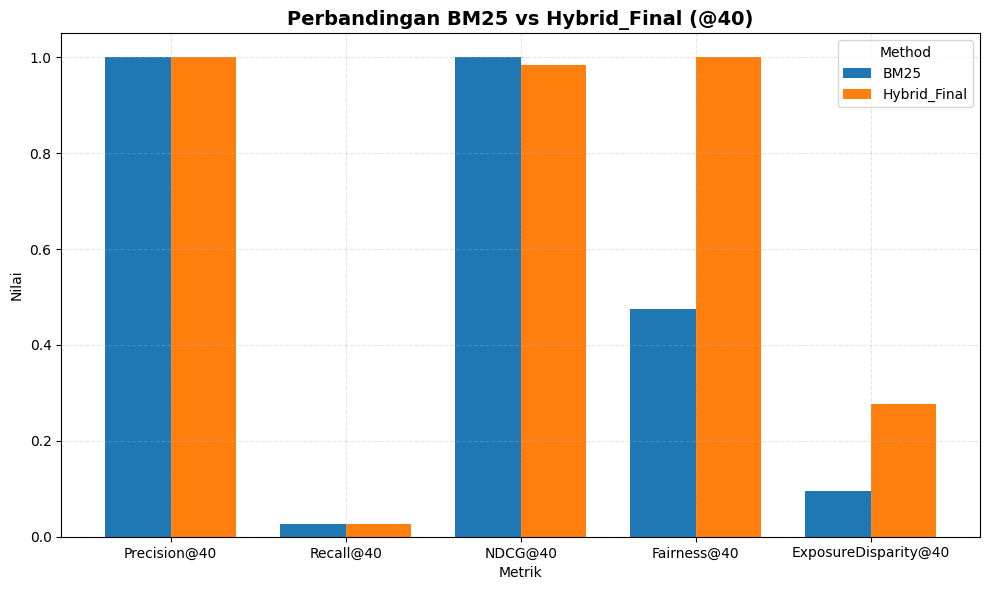

In [5]:
df_plot = df_summary.set_index('method')[metric_cols].T

ax = df_plot.plot(kind='bar', width=0.75)
ax.set_title('Perbandingan BM25 vs Hybrid_Final (@40)', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrik')
ax.set_ylabel('Nilai')
ax.set_xticklabels(df_plot.index, rotation=0)
plt.legend(title='Method')
plt.tight_layout()
plt.show()

### 2. Selisih Hybrid_Final terhadap BM25

Grafik ini membantu melihat trade-off dengan lebih jelas.
- nilai positif = Hybrid lebih tinggi dari BM25
- nilai negatif = Hybrid lebih rendah dari BM25

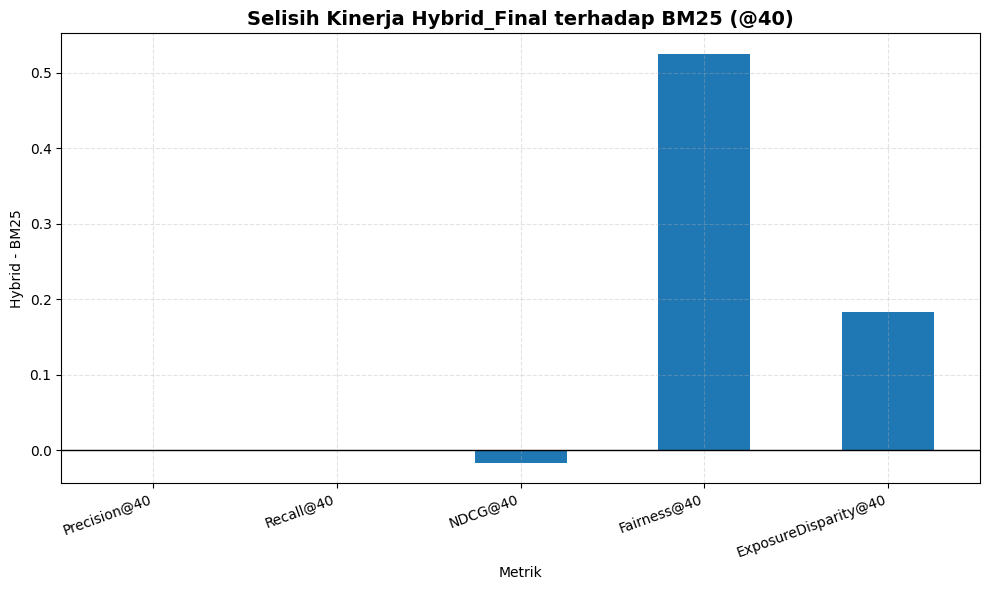

In [6]:
df_idx = df_summary.set_index('method')

diff = df_idx.loc['Hybrid_Final', metric_cols] - df_idx.loc['BM25', metric_cols]
diff_df = diff.reset_index()
diff_df.columns = ['metric', 'difference']

ax = diff_df.plot(x='metric', y='difference', kind='bar', legend=False)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Selisih Kinerja Hybrid_Final terhadap BM25 (@40)', fontsize=14, fontweight='bold')
ax.set_xlabel('Metrik')
ax.set_ylabel('Hybrid - BM25')
ax.set_xticklabels(diff_df['metric'], rotation=20, ha='right')
plt.tight_layout()
plt.show()

### 3. Fairness vs Exposure Disparity

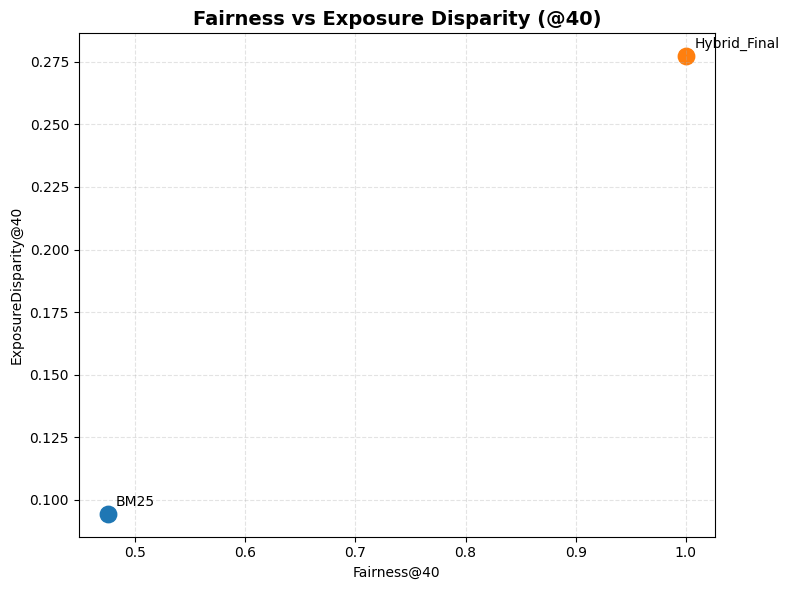

In [7]:
fairness_col = [c for c in metric_cols if 'Fairness' in c][0]
exposure_col = [c for c in metric_cols if 'ExposureDisparity' in c][0]

plt.figure(figsize=(8, 6))

for _, row in df_summary.iterrows():
    plt.scatter(row[fairness_col], row[exposure_col], s=140)
    plt.annotate(
        row['method'],
        (row[fairness_col], row[exposure_col]),
        xytext=(6, 6),
        textcoords='offset points'
    )

plt.title('Fairness vs Exposure Disparity (@40)', fontsize=14, fontweight='bold')
plt.xlabel(fairness_col)
plt.ylabel(exposure_col)
plt.tight_layout()
plt.show()

### 4. Precision per Query

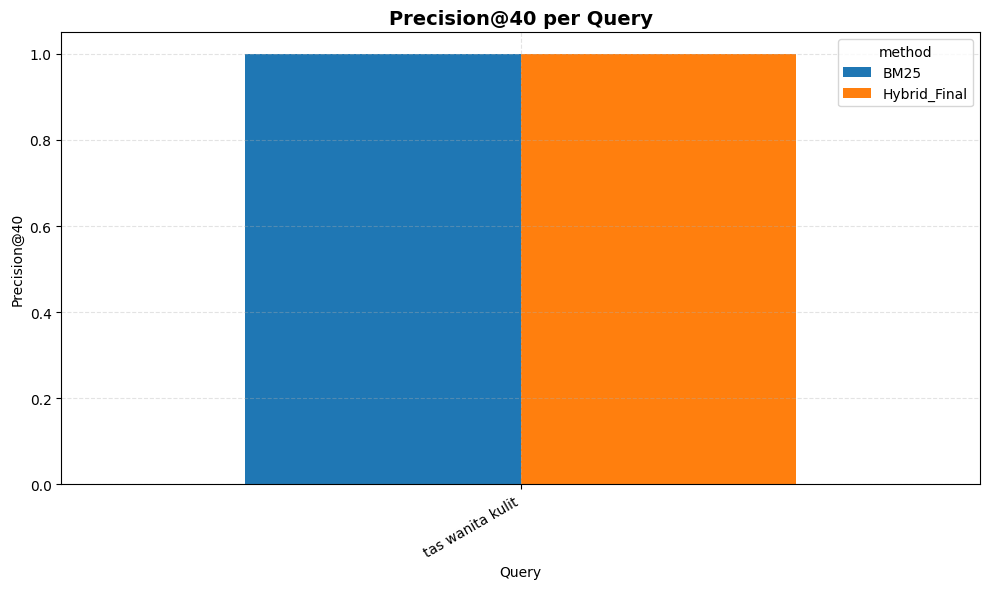

In [8]:
precision_col = [c for c in metric_cols if 'Precision' in c][0]
pivot_precision = df_eval.pivot(index='query', columns='method', values=precision_col)

ax = pivot_precision.plot(kind='bar', width=0.75)
ax.set_title(f'{precision_col} per Query', fontsize=14, fontweight='bold')
ax.set_xlabel('Query')
ax.set_ylabel(precision_col)
ax.set_xticklabels(pivot_precision.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 5. Recall per Query

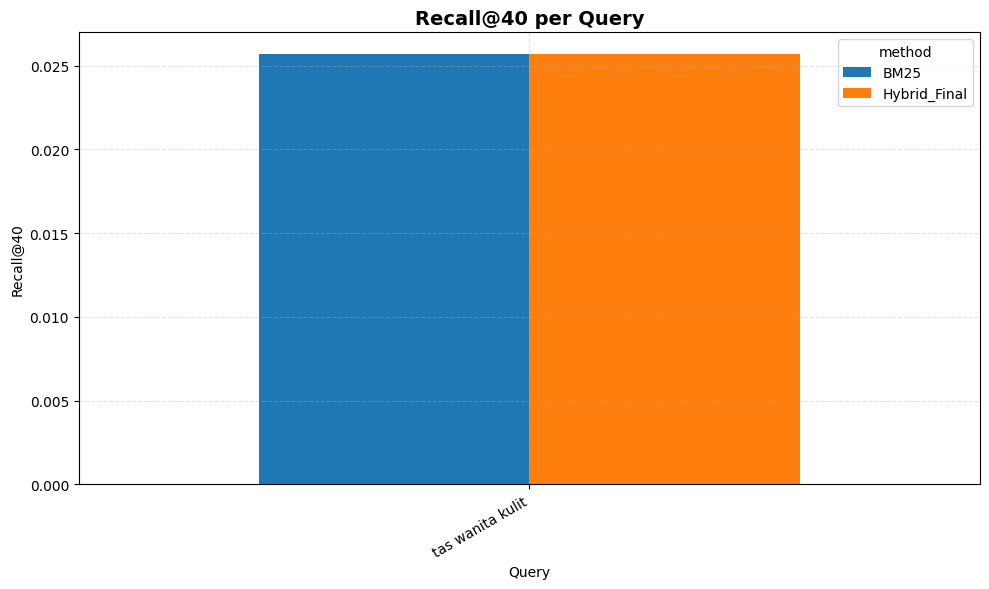

In [9]:
recall_col = [c for c in metric_cols if 'Recall' in c][0]
pivot_recall = df_eval.pivot(index='query', columns='method', values=recall_col)

ax = pivot_recall.plot(kind='bar', width=0.75)
ax.set_title(f'{recall_col} per Query', fontsize=14, fontweight='bold')
ax.set_xlabel('Query')
ax.set_ylabel(recall_col)
ax.set_xticklabels(pivot_recall.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 6. NDCG per Query

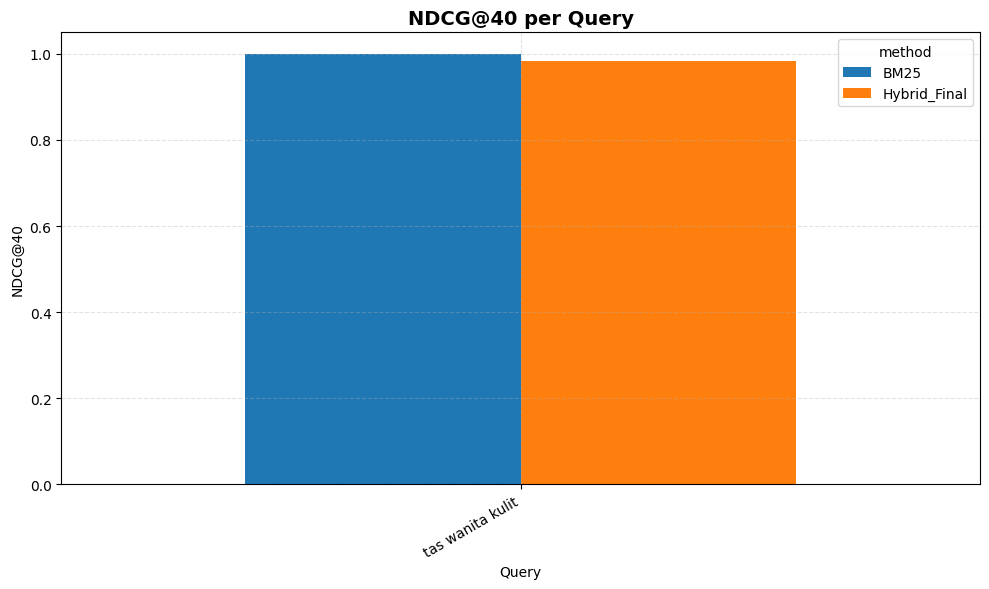

In [10]:
ndcg_col = [c for c in metric_cols if 'NDCG' in c][0]
pivot_ndcg = df_eval.pivot(index='query', columns='method', values=ndcg_col)

ax = pivot_ndcg.plot(kind='bar', width=0.75)
ax.set_title(f'{ndcg_col} per Query', fontsize=14, fontweight='bold')
ax.set_xlabel('Query')
ax.set_ylabel(ndcg_col)
ax.set_xticklabels(pivot_ndcg.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()

### 7. Fairness per Query

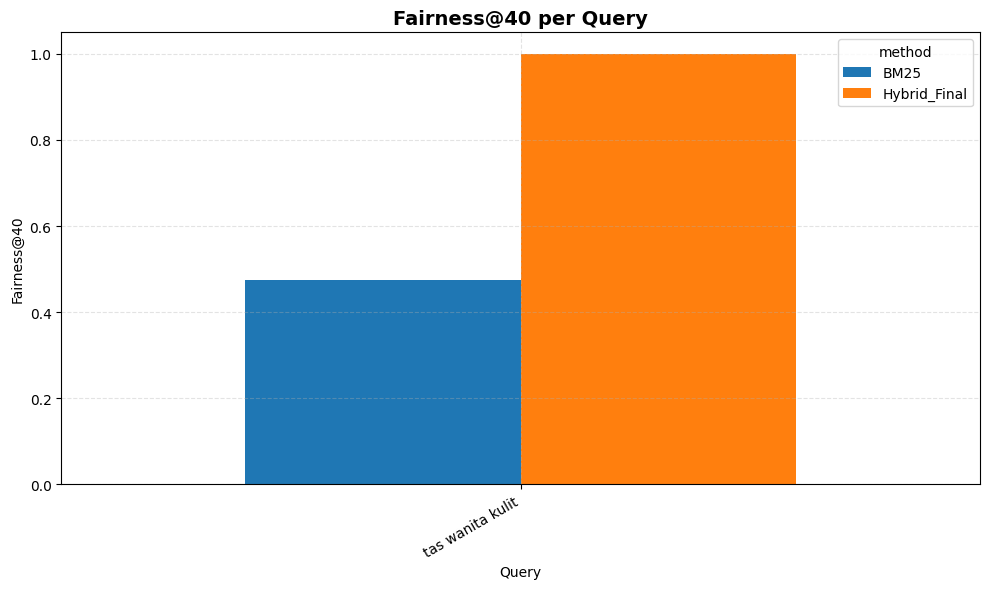

In [11]:
pivot_fairness = df_eval.pivot(index='query', columns='method', values=fairness_col)

ax = pivot_fairness.plot(kind='bar', width=0.75)
ax.set_title(f'{fairness_col} per Query', fontsize=14, fontweight='bold')
ax.set_xlabel('Query')
ax.set_ylabel(fairness_col)
ax.set_xticklabels(pivot_fairness.index, rotation=30, ha='right')
plt.tight_layout()
plt.show()